# Business Problem Understanding
The goal is to predict the rent of a house based on features like area, location, number of rooms, etc

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Data Collection

In [2]:
df=pd.read_csv(r"C:\Users\chitt\Downloads\data.csv")
df

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0
...,...,...,...,...,...,...,...,...,...,...
7686,"3 BHK Flat for Rent in Saket, New Delhi",Saket,New Delhi,1750.0,3,3,0,Furnished,27.0,47000.0
7687,"2 BHK Flat for Rent in Phase 7 JP Nagar, Banga...",Phase 7 JP Nagar,Bangalore,1050.0,2,2,2,Semi-Furnished,27.0,28000.0
7688,"2 BHK Flat for Rent in Malpani Vivanta, Balewa...",Balewadi,Pune,734.0,2,2,2,Unfurnished,48.0,35000.0
7689,"1 BHK Flat for Rent in Shalimar bagh, New Delhi",Shalimar bagh,New Delhi,400.0,1,1,0,Semi-Furnished,38.0,15000.0


# DATA UNDERSTANDING

# About Data

->house_type: Description of the property including BHK type and building/project name (e.g., 2 BHK Flat for Rent in Oberoi Woods)
->locality: Specific area or neighborhood where the property is located (e.g., Goregaon East, Powai)
->city: City in which the property is located (e.g., Mumbai, Pune, Nagpur)
->area: Size of the property in square feet (e.g., 897.0, 490.0)
->beds: Number of bedrooms in the property (e.g., 1, 2)
->bathrooms: Number of bathrooms available in the property (e.g., 1, 2)
->balconies: Number of balconies in the property (e.g., 0)
->furnishing: Furnishing status of the property (Furnished, Semi-Furnished, Unfurnished)
->area_rate: Rent per square foot of the property (e.g., 134.0, 82.0)
->rent: Total monthly rent of the property in rupees (target variable) 🎯

Target variable is rent because we are predicting house prices”

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   object 
 1   locality    7691 non-null   object 
 2   city        7691 non-null   object 
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   object 
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 601.0+ KB


In [4]:
df.head()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0


In [5]:
# missing values
df.isnull().sum()

house_type    0
locality      0
city          0
area          0
beds          0
bathrooms     0
balconies     0
furnishing    0
area_rate     0
rent          0
dtype: int64

In [6]:
#statistical summary
df.describe()

,area,beds,bathrooms,balconies,area_rate,rent
count,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7.691000e+03
mean,1106.354180,2.208685,2.137043,0.817319,47.619989,5.479508e+04
std,1197.426843,0.993481,1.027677,1.243361,68.989657,9.742006e+04
min,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000e+03
25%,600.000000,1.000000,1.000000,0.000000,21.000000,1.500000e+04
50%,900.000000,2.000000,2.000000,0.000000,31.000000,2.800000e+04
75%,1300.000000,3.000000,3.000000,2.000000,54.000000,5.700000e+04
max,70000.000000,10.000000,10.000000,10.000000,2586.000000,2.700000e+06


# EDA (Exploratory Data Analysis)

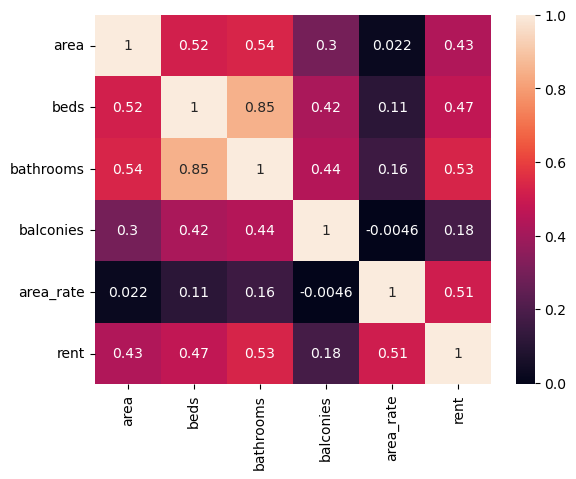

In [7]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

<Axes: xlabel='furnishing'>

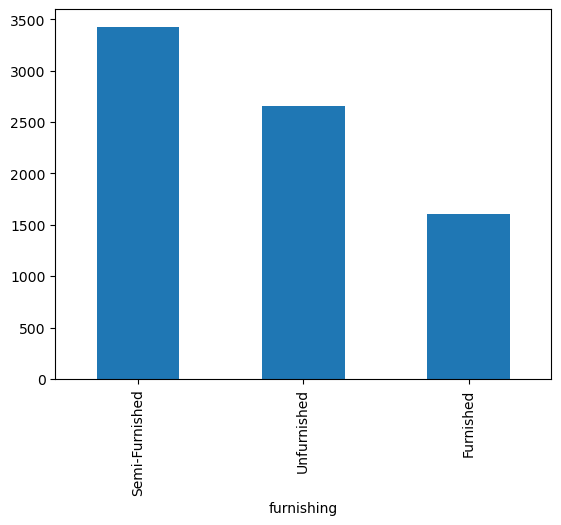

In [8]:
df["furnishing"].value_counts().plot(kind="bar")

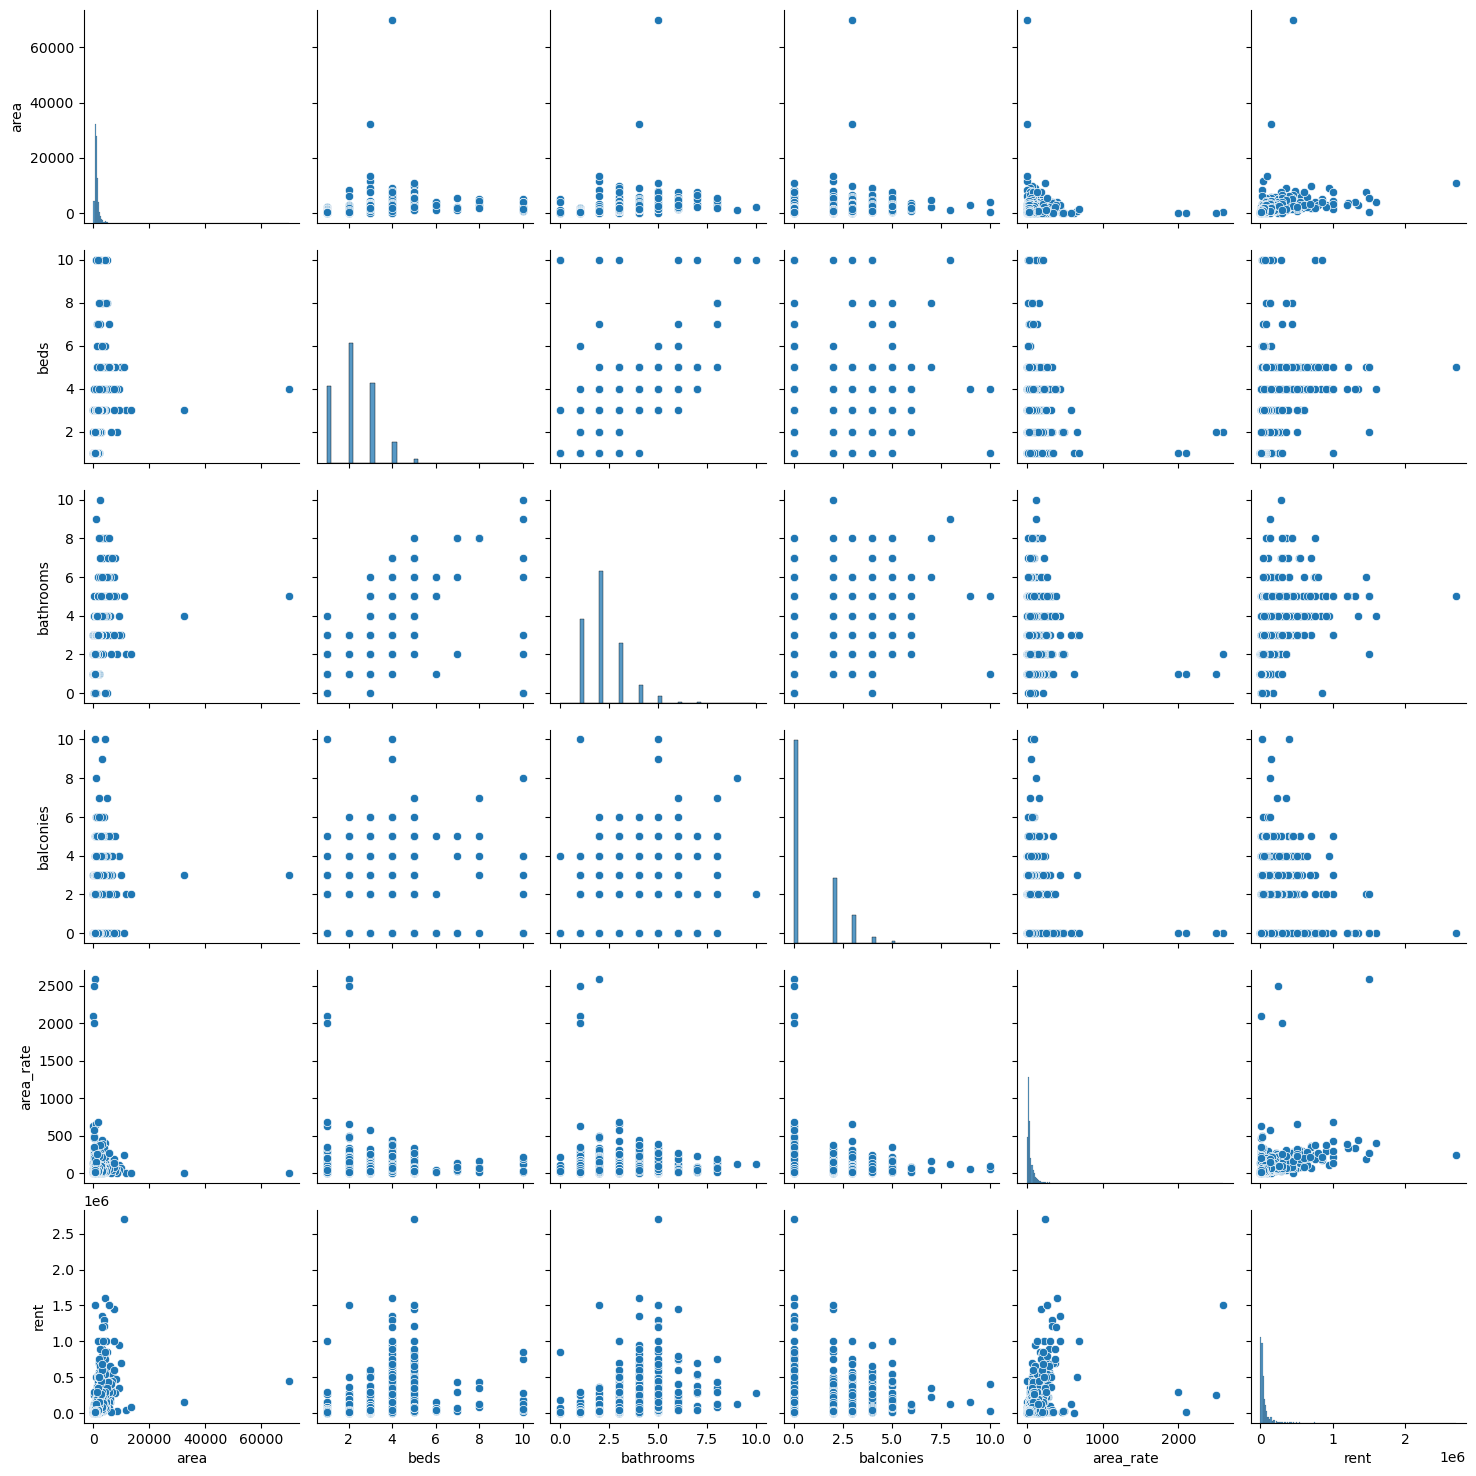

In [9]:
#Performed visualization using pairplot to understand relationships between variables
sns.pairplot(df)
plt.show()

# Data Preprocessing

In [10]:
#1. Handle Missing Values
df.isnull().sum()

house_type    0
locality      0
city          0
area          0
beds          0
bathrooms     0
balconies     0
furnishing    0
area_rate     0
rent          0
dtype: int64

In [11]:
# 2. Remove Duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [12]:
#Dropped unnecessary column:
df.drop(columns=["house_type"],inplace=True)
df.head()

,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0


# Data Wrangling / Feature Engineering

In [13]:
# Categorical features such as city and furnishing are converted into numerical values using Label Encoding.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["city"] = le.fit_transform(df["city"])
df["furnishing"] = le.fit_transform(df["furnishing"])

#The locality column is removed because it contains a large number of unique values, which increases model complexity.
df.drop("locality", axis=1, inplace=True)

df.head()

,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,1,897.0,2,2,0,1,134.0,120000.0
1,1,490.0,1,1,0,1,82.0,40000.0
2,4,550.0,1,1,0,2,22.0,12000.0
3,2,1000.0,2,2,0,2,8.0,8000.0
4,1,595.0,1,1,0,2,25.0,15000.0


# Train-Test Split

In [14]:
#The independent variables (features) are stored in X, and the dependent variable (target) is stored in y.
X = df.drop('rent', axis=1)
y = df['rent']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
X_train.shape

(6152, 7)

# Model Building

Train Normal Linear Regression

In [16]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

Train Polynomial Regression

In [17]:
from sklearn.model_selection import train_test_split

# Step 1: Split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Apply Polynomial ONLY on train
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Compare Both Models

In [19]:
#Both Linear Regression and Polynomial Regression models were trained.
#Their performance was compared using error metrics, and the model with better accuracy was selected.

from sklearn.metrics import mean_squared_error

print("Linear MSE:", mean_squared_error(y_test, y_pred1))
print("Polynomial MSE:", mean_squared_error(y_test, y_pred1))

Linear MSE: 15453417886.043509
Polynomial MSE: 15453417886.043509


Polynomial Regression was selected as the final model for predicting house rent.

In [20]:
model2.intercept_

np.float64(-384.3013391955974)

In [21]:
model2.coef_

array([-2.58437676e-07,  2.11331501e+02, -9.20266441e-01,  5.65359314e+02,
       -3.17786336e+01, -4.76795940e+01,  1.49318076e+02,  4.36111081e+00,
       -4.81542765e+01, -7.53354376e-02, -3.93094999e+01,  9.52353207e+01,
        1.56121560e+01, -5.41644381e-01, -1.16066074e+00,  8.28129083e-06,
        5.48892539e-02,  5.98438770e-02,  5.92183858e-02,  6.40337846e-02,
        1.00249326e+00, -5.51887049e+01, -1.11455398e+01,  1.38767687e+01,
       -2.92863996e+01,  2.45397312e-01,  2.12646834e+01,  1.74339635e+01,
       -4.62621965e+01, -9.66998268e-01, -4.25447626e+01, -5.87220151e+00,
        1.49149349e-01, -3.16119940e+01, -5.28970050e-01, -1.22705219e-03])

In [22]:
# prediction
train_predictions=model2.predict(X_train_poly)
test_predictions=model2.predict(X_test_poly)

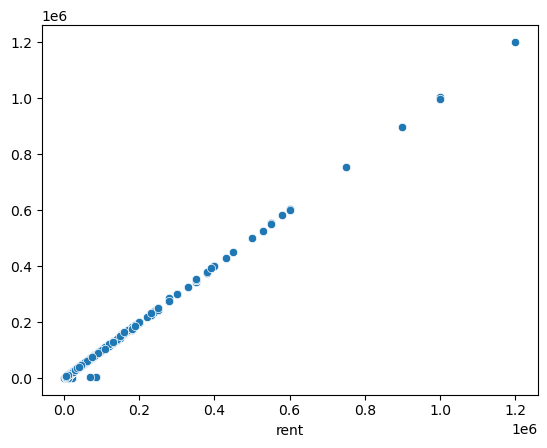

In [23]:
sns.scatterplot(x=y_test, y=test_predictions)
plt.show()

# Evalution

In [24]:
model2.score(X_train_poly, y_train)

0.9996594474846536

In [25]:
from sklearn.metrics import r2_score
print("R2 for test data: ",r2_score(y_test,test_predictions))
print("R2 for train data: ",r2_score(y_train,train_predictions))

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model2, X_train_poly, y_train, cv=5)
cv_score = scores.mean()

cv_score = scores.mean()
print("Cross Validation Score:", cv_score)

R2 for test data:  0.9987602608002141
R2 for train data:  0.9996594474846536
Cross Validation Score: 0.9994950029600338


# Ridge Regression With default Parameters

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('ridge', Ridge(alpha=10))
])

pipeline.fit(X_train, y_train)

train_predictions = pipeline.predict(X_train)
test_predictions = pipeline.predict(X_test)

from sklearn.metrics import r2_score
print("R2 train:", r2_score(y_train, train_predictions))
print("R2 test:", r2_score(y_test, test_predictions))

scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print("CV Score:", scores.mean())

R2 train: 0.9996594433400293
R2 test: 0.9987603924970558
CV Score: 0.9994957689310391


Earlier, the model showed signs of overfitting due to polynomial features.
This was resolved by applying transformation after train-test split.

# Conclusion:
- Polynomial regression improved performance over linear regression
- Proper preprocessing avoided data leakage
- Cross-validation ensured model reliability
- Final model performs well on unseen data